In [89]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [90]:
df = pd.read_csv("smartcart_customers.csv")

In [91]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [92]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Handling Missing Values


In [93]:
df["Income"] = df["Income"].fillna(df['Income'].median())

In [94]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering


In [95]:
df["Age"] = df["Year_Birth"].max()-df["Year_Birth"]

In [96]:
df["Study"] = df["Education"].replace({"Graduation":"Graduation","PhD":"PostGraduation","Master":"PostGraduation","2n Cycle":"PostGraduation","Basic":"UnderGraduate"})

In [97]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Study
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,3,8,10,4,7,0,1,39,Graduation
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,6,2,1,1,2,5,0,0,42,Graduation
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,42,1,8,2,10,4,0,0,31,Graduation
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,5,2,2,0,4,6,0,0,12,Graduation
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,15,5,5,3,6,5,0,0,15,PostGraduation


In [98]:
df["Study"].value_counts()

Study
Graduation        1127
PostGraduation    1059
UnderGraduate       54
Name: count, dtype: int64

In [99]:
df["Relationship"] = df['Marital_Status'].map({
    "Widow": 0,
    "Single":0,
    "Divorced":0,
    "Alone": 0,
    "Absurd": 0,  
    "YOLO": 0,
    "Married":1,
    "Together":1,
    
})

In [100]:
df["Relationship"].value_counts().sum()

np.int64(2240)

In [101]:
df["children"] = df["Kidhome"]+df["Teenhome"]

In [102]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

In [103]:
df["days"]=df["Dt_Customer"].max() - df['Dt_Customer']

In [104]:
df["days"] = pd.to_timedelta(df["days"]).dt.days

In [105]:
df["Purchace"] = df["MntWines"]	+df["MntFruits"]+df["MntMeatProducts"]	+df["MntFishProducts"]+	df["MntSweetProducts"]	+df["MntGoldProds"]+df["NumDealsPurchases"]+df["NumWebPurchases"]

In [106]:
drop_column = ["MntWines","Dt_Customer","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",'ID', 'Year_Birth', 'Education', 'Marital_Status', 'Kidhome',
       'Teenhome']

In [107]:
fresh_df = df.drop(drop_column,axis=1)

# Outliyer

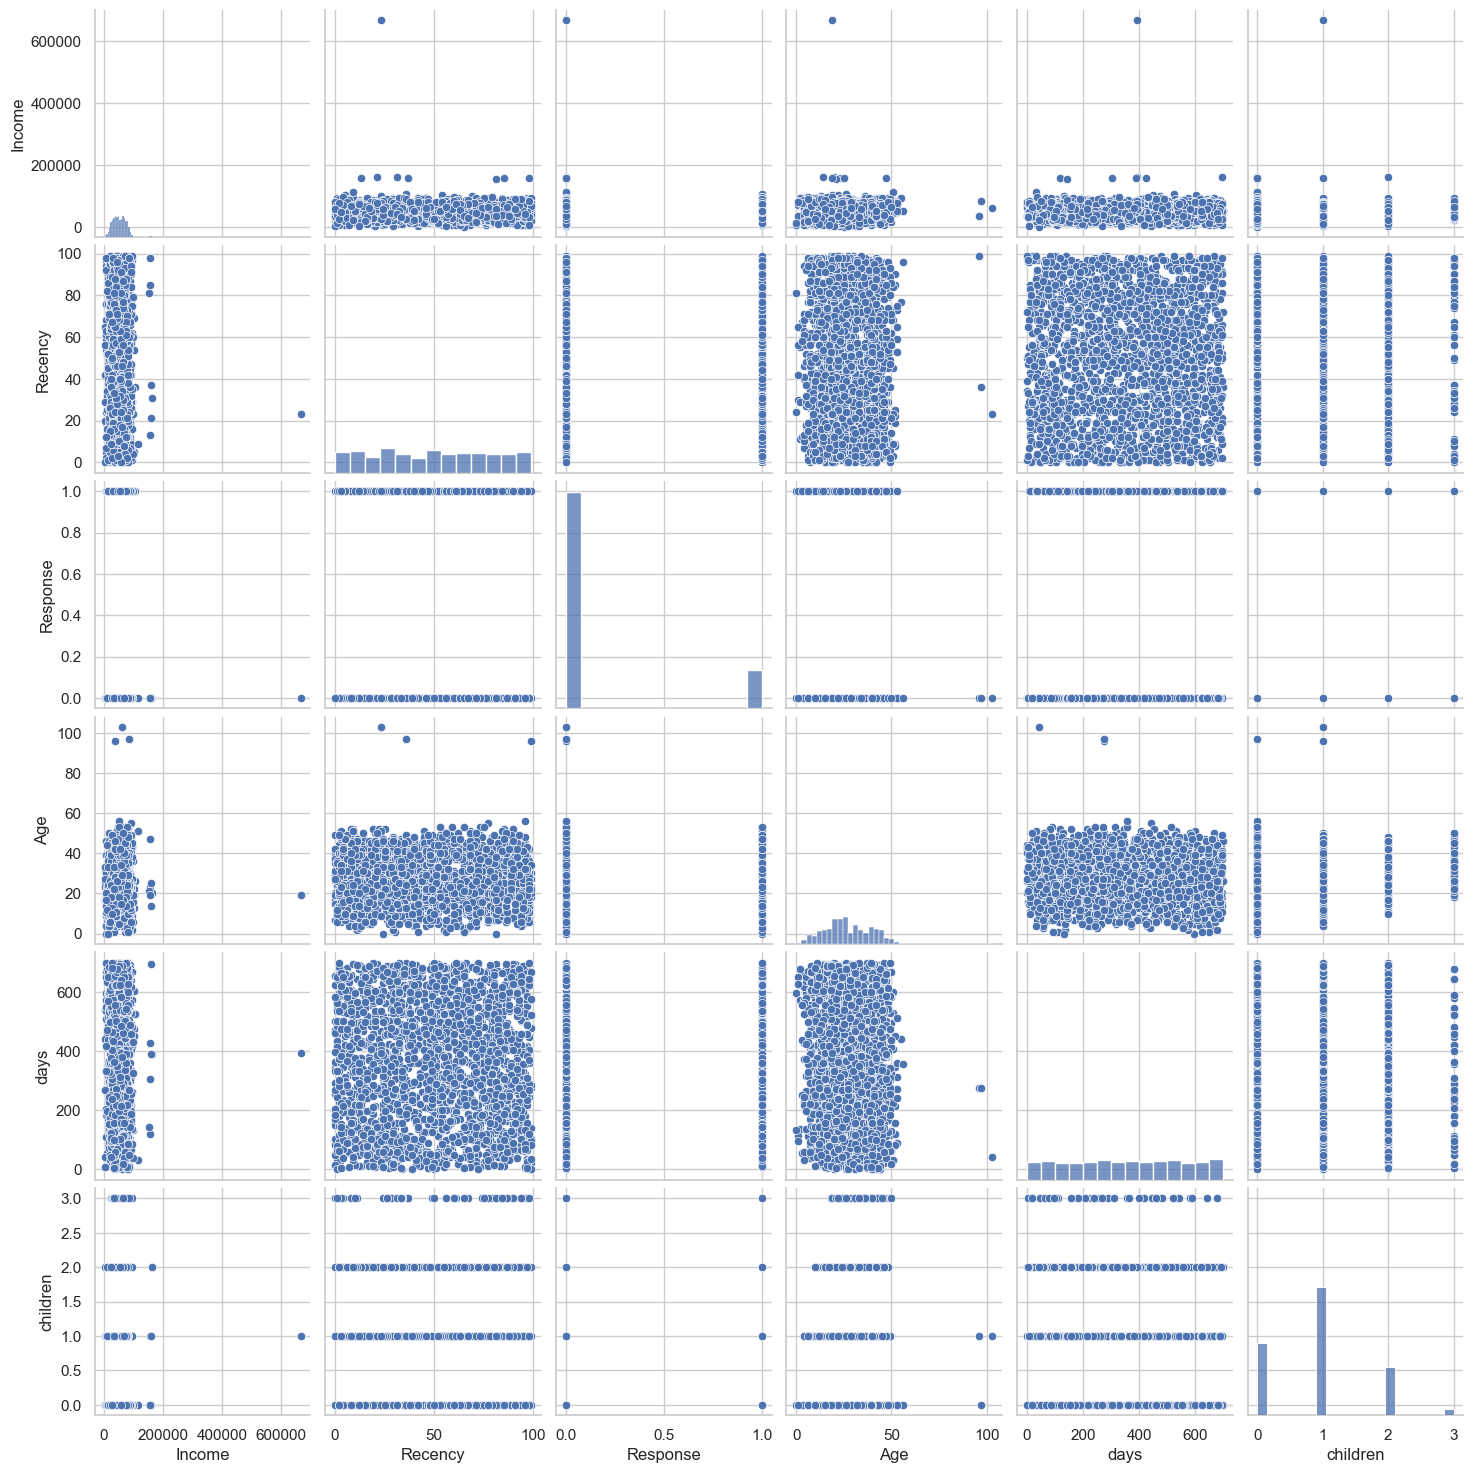

In [108]:
cols = ["Income", "Recency", "Response", "Age", "days", "children"]

# relative plots of some features-  pair plots
sns.pairplot(fresh_df[cols])

In [109]:
fresh_df=fresh_df[fresh_df["Age"]<90]

In [110]:
fresh_df=fresh_df[fresh_df['Income']<600000]

In [111]:
fresh_df

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Study,Relationship,children,days,Purchace
0,58138.0,58,3,8,10,4,7,0,1,39,Graduation,0,0,663,1628
1,46344.0,38,2,1,1,2,5,0,0,42,Graduation,0,2,113,30
2,71613.0,26,1,8,2,10,4,0,0,31,Graduation,1,0,312,785
3,26646.0,26,2,2,0,4,6,0,0,12,Graduation,1,1,139,57
4,58293.0,94,5,5,3,6,5,0,0,15,PostGraduation,1,1,161,432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,29,Graduation,1,1,381,1352
2236,64014.0,56,7,8,2,5,7,0,0,50,PostGraduation,1,3,19,459
2237,56981.0,91,1,2,3,13,6,0,0,15,Graduation,0,0,155,1244
2238,69245.0,8,2,6,5,10,3,0,0,40,PostGraduation,1,1,156,851


# Encoding

In [112]:
ohe = OneHotEncoder(drop="first", sparse_output=False)
encoded = ohe.fit_transform(fresh_df[['Relationship', 'Study']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Relationship', 'Study']),
    index=fresh_df.index
)
cleaned_data = pd.concat([fresh_df, encoded_df], axis=1)

In [113]:
cleaned_data=cleaned_data.drop(['Relationship', 'Study'],axis=1)

In [114]:
correlation=cleaned_data.corr()

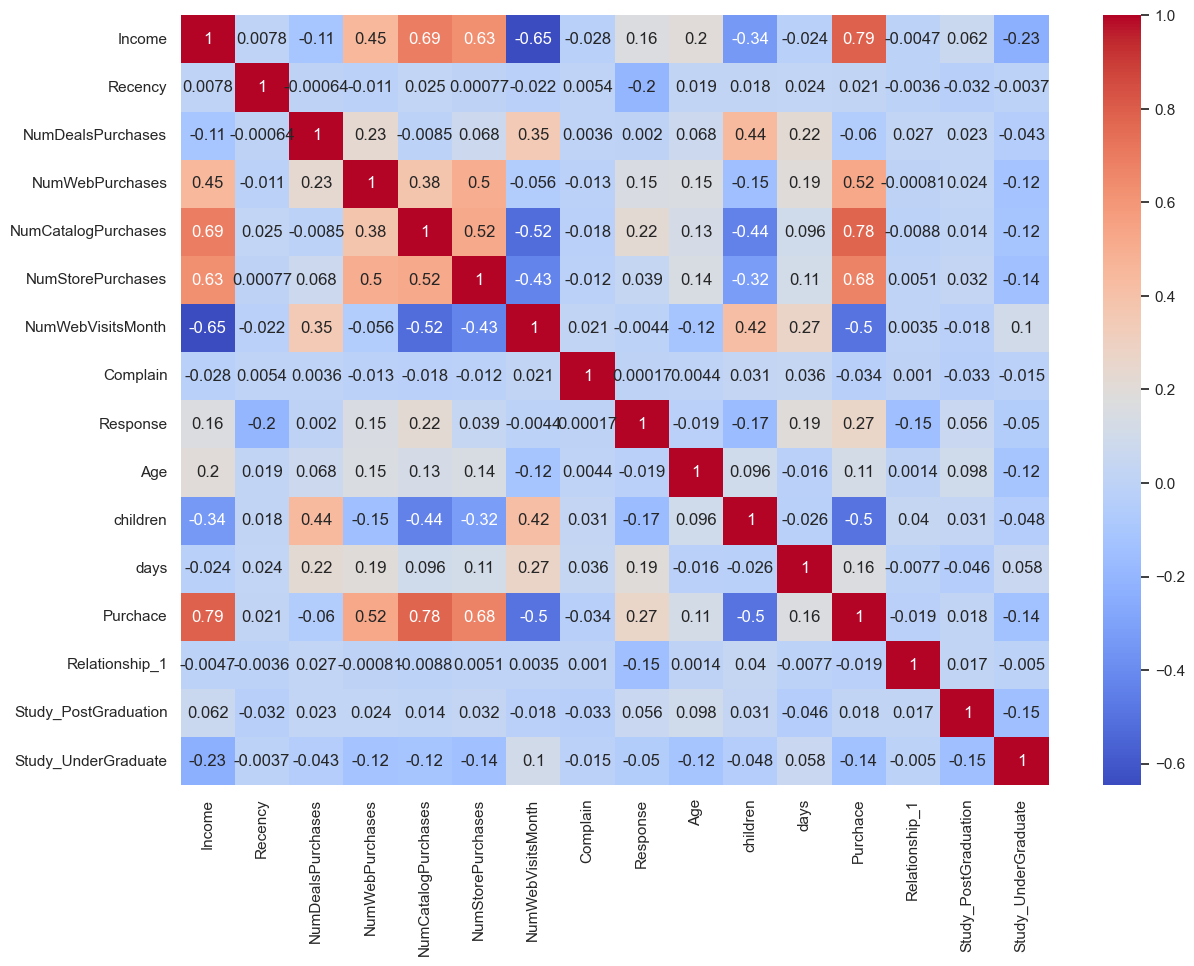

In [115]:
plt.figure(figsize=(14,10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

# Scaling

In [116]:
scale = StandardScaler()

In [117]:
X_Scaled = scale.fit_transform(cleaned_data)

# PCA

In [118]:
pca = PCA(n_components=3)

In [119]:
pca_data = pca.fit_transform(X_Scaled)

In [120]:
pca.explained_variance_ratio_

array([0.26112266, 0.11339833, 0.08870337])

# Visualize

Text(0.5, 0, 'PCA 3')

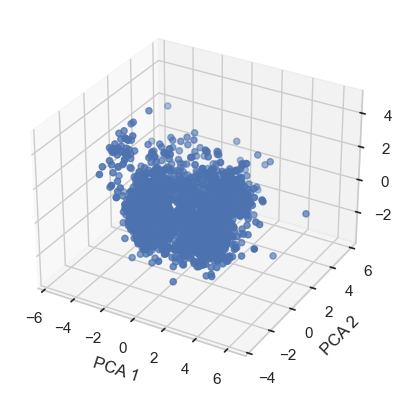

In [121]:
sns.set(style="whitegrid")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

# Optimal K Value Analysis

# 1) Elbow Method

In [122]:
wcss = []
for k in range(1,11):
    kmean = KMeans(n_clusters=k)
    kmean.fit_predict(pca_data)
    wcss.append(kmean.inertia_)
    

<Axes: >

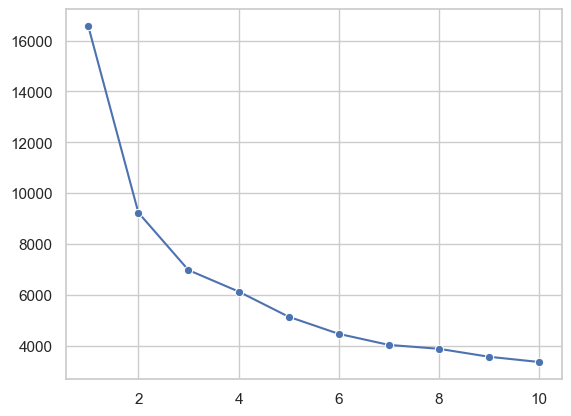

In [123]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [ ]:
knee = KneeLocator(range(1,11), wcss, S=1.0, curve="convex", direction="decreasing")
knee.elbow

np.int64(3)

In [149]:
scores = []
for k in range(2,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    labels = kmean.fit_predict(pca_data)
    score = silhouette_score(pca_data,labels)
    scores.append(score)
    

Text(0, 0.5, 'Silhouette score')

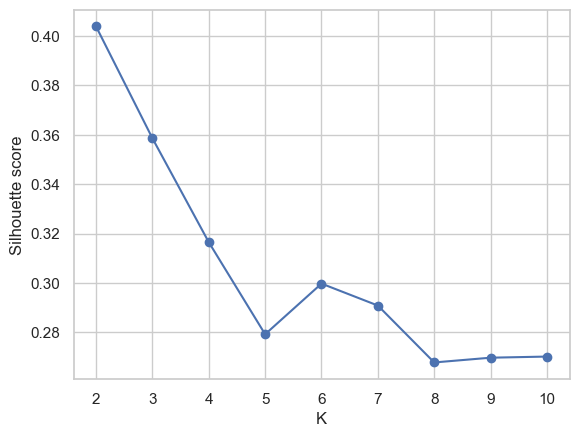

In [150]:
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

# combined plot

Text(0, 0.5, 'SS')

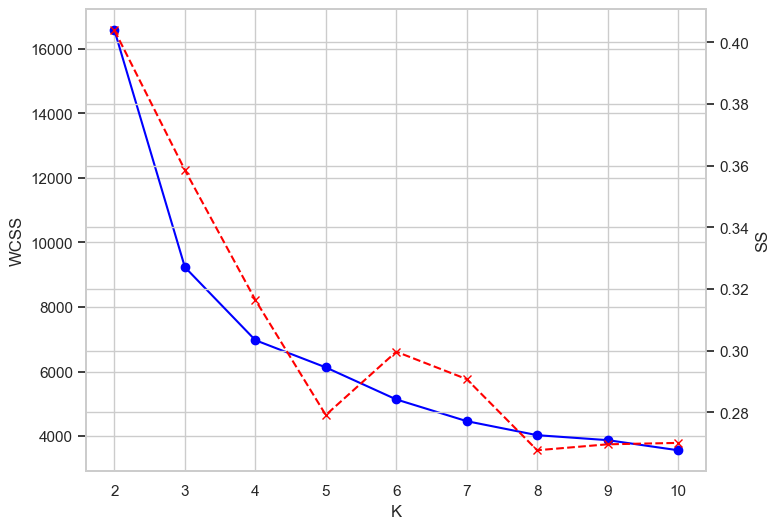

In [151]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [152]:
cleaned_data.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,children,days,Purchace,Relationship_1,Study_PostGraduation,Study_UnderGraduate
0,58138.0,58,3,8,10,4,7,0,1,39,0,663,1628,0.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,42,2,113,30,0.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,31,0,312,785,1.0,0.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,12,1,139,57,1.0,0.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,15,1,161,432,1.0,1.0,0.0


# Clustering


# 1)Kmean

In [162]:
kmean = KMeans(n_clusters=3,random_state=42)
labels = kmean.fit_predict(pca_data)

Text(0.5, 0, 'PCA 3')

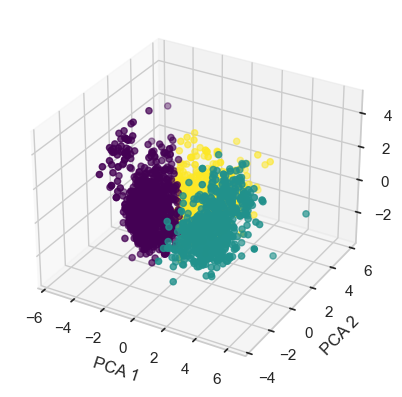

In [166]:
sns.set(style="whitegrid")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2], c =labels, cmap='viridis' )

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

# 2) Agglomerative

In [178]:
agl_clf = AgglomerativeClustering(n_clusters=3)
agl_label = agl_clf.fit_predict(pca_data)

Text(0.5, 0, 'PCA 3')

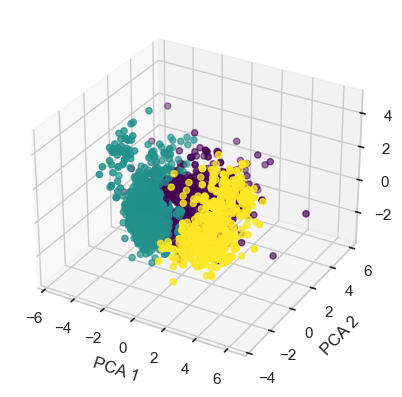

In [179]:
sns.set(style="whitegrid")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2], c =agl_label, cmap='viridis' )

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

# Cluster Characterization

In [203]:
cleaned_data["clusters"] = agl_label

In [204]:
panel=["red", "blue", "yellow"]

<Axes: xlabel='clusters', ylabel='count'>

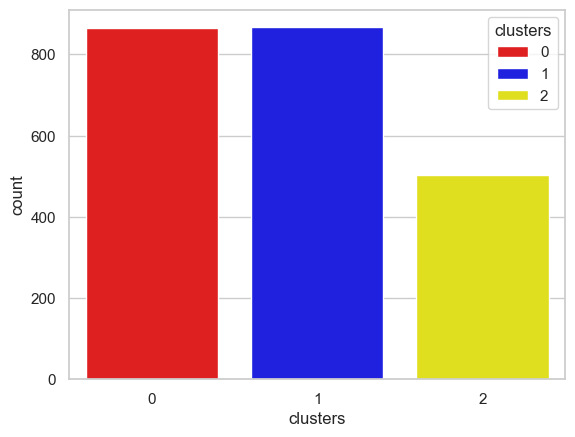

In [205]:
sns.countplot(x=cleaned_data["clusters"],palette=panel,hue=cleaned_data["clusters"])

<Axes: xlabel='Purchace', ylabel='Income'>

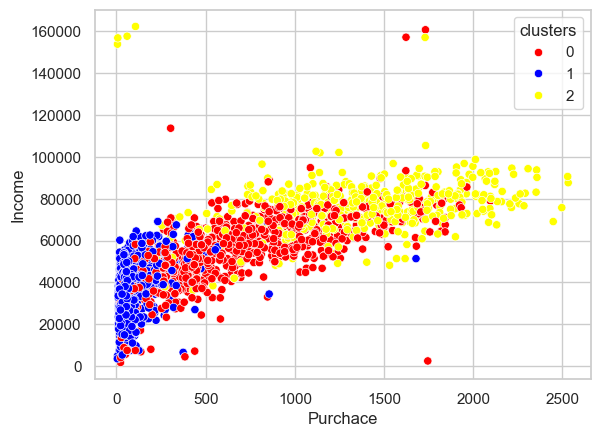

In [206]:
sns.scatterplot(x=cleaned_data["Purchace"],y=cleaned_data["Income"],palette=panel,hue=cleaned_data["clusters"])

In [209]:
cleaned_data.groupby("clusters").mean().sort_values(by="Income")

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,children,days,Purchace,Relationship_1,Study_PostGraduation,Study_UnderGraduate
clusters,,,,,,,,,,,,,,,,
1,34545.294694,48.635525,1.711649,1.921569,0.505190,3.185698,6.206459,0.008074,0.081892,23.376009,1.140715,291.009227,94.815456,0.647059,0.440600,0.062284
0,54979.222286,49.555427,3.684758,5.841801,2.906467,6.988453,6.053118,0.012702,0.108545,30.816397,1.256351,430.890300,692.700924,0.675520,0.506928,0.000000
2,76746.059642,49.188867,1.045726,4.801193,5.964215,8.240557,2.524851,0.003976,0.335984,27.129225,0.097416,329.186879,1366.288270,0.588469,0.467197,0.000000
